In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DailyDelhiClimateTest.csv')
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
...,...,...,...,...,...
109,2017-04-20,34.500000,27.500000,5.562500,998.625000
110,2017-04-21,34.250000,39.375000,6.962500,999.875000
111,2017-04-22,32.900000,40.900000,8.890000,1001.600000
112,2017-04-23,32.875000,27.500000,9.962500,1002.125000


In [4]:
df['date'] = pd.to_datetime(df['date'])
df['age'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [5]:
df['humidity_norm'] = df['humidity'] / 50.0
df['wind_speed_norm'] = df['wind_speed'] / 50.0
df['meanpressure_norm'] = df['meanpressure'] / 1000.0

In [6]:
lags = 3
for lag in range(1, lags + 1):
    df[f'lag_{lag}_humidity'] = df['humidity_norm'].shift(lag)
    df[f'lag_{lag}_wind_speed'] = df['wind_speed_norm'].shift(lag)
    df[f'lag_{lag}_meanpressure'] = df['meanpressure_norm'].shift(lag)

In [7]:
df['mean_humidity'] = df[[f'lag_{k}_humidity' for k in range(1, 4)]].mean(axis=1)
df['mean_wind_speed'] = df[[f'lag_{k}_wind_speed' for k in range(1, 4)]].mean(axis=1)
df['mean_meanpressure'] = df[[f'lag_{k}_meanpressure' for k in range(1, 4)]].mean(axis=1)
df.head()

,date,meantemp,humidity,wind_speed,meanpressure,age,month,day,humidity_norm,wind_speed_norm,...,lag_1_meanpressure,lag_2_humidity,lag_2_wind_speed,lag_2_meanpressure,lag_3_humidity,lag_3_wind_speed,lag_3_meanpressure,mean_humidity,mean_wind_speed,mean_meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1,1,1.717391,0.054870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1,2,1.544444,0.057889,...,0.059000,NaN,NaN,NaN,NaN,NaN,NaN,1.717391,0.054870,0.059000
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1,3,1.637778,0.080333,...,1.018278,1.717391,0.054870,0.059000,NaN,NaN,NaN,1.630918,0.056379,0.538639
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1,4,1.401000,0.090900,...,1.018333,1.544444,0.057889,1.018278,1.717391,0.054870,0.059000,1.633205,0.064364,0.698537
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1,5,1.498889,0.066000,...,1.015700,1.637778,0.080333,1.018333,1.544444,0.057889,1.018278,1.527741,0.076374,1.017437


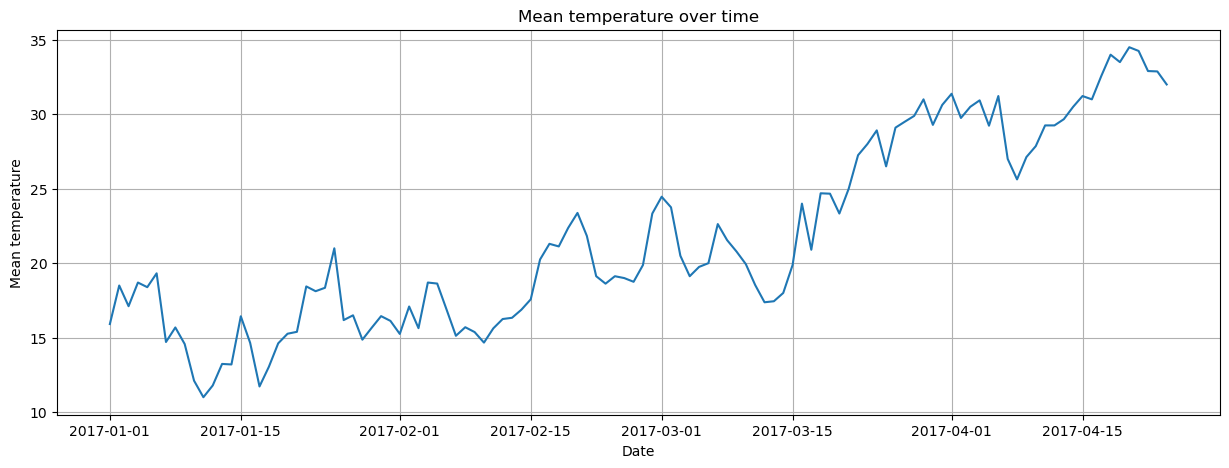

In [9]:
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['meantemp'])
plt.title('Mean temperature over time')
plt.xlabel('Date')
plt.ylabel('Mean temperature')
plt.grid(True)
plt.show()

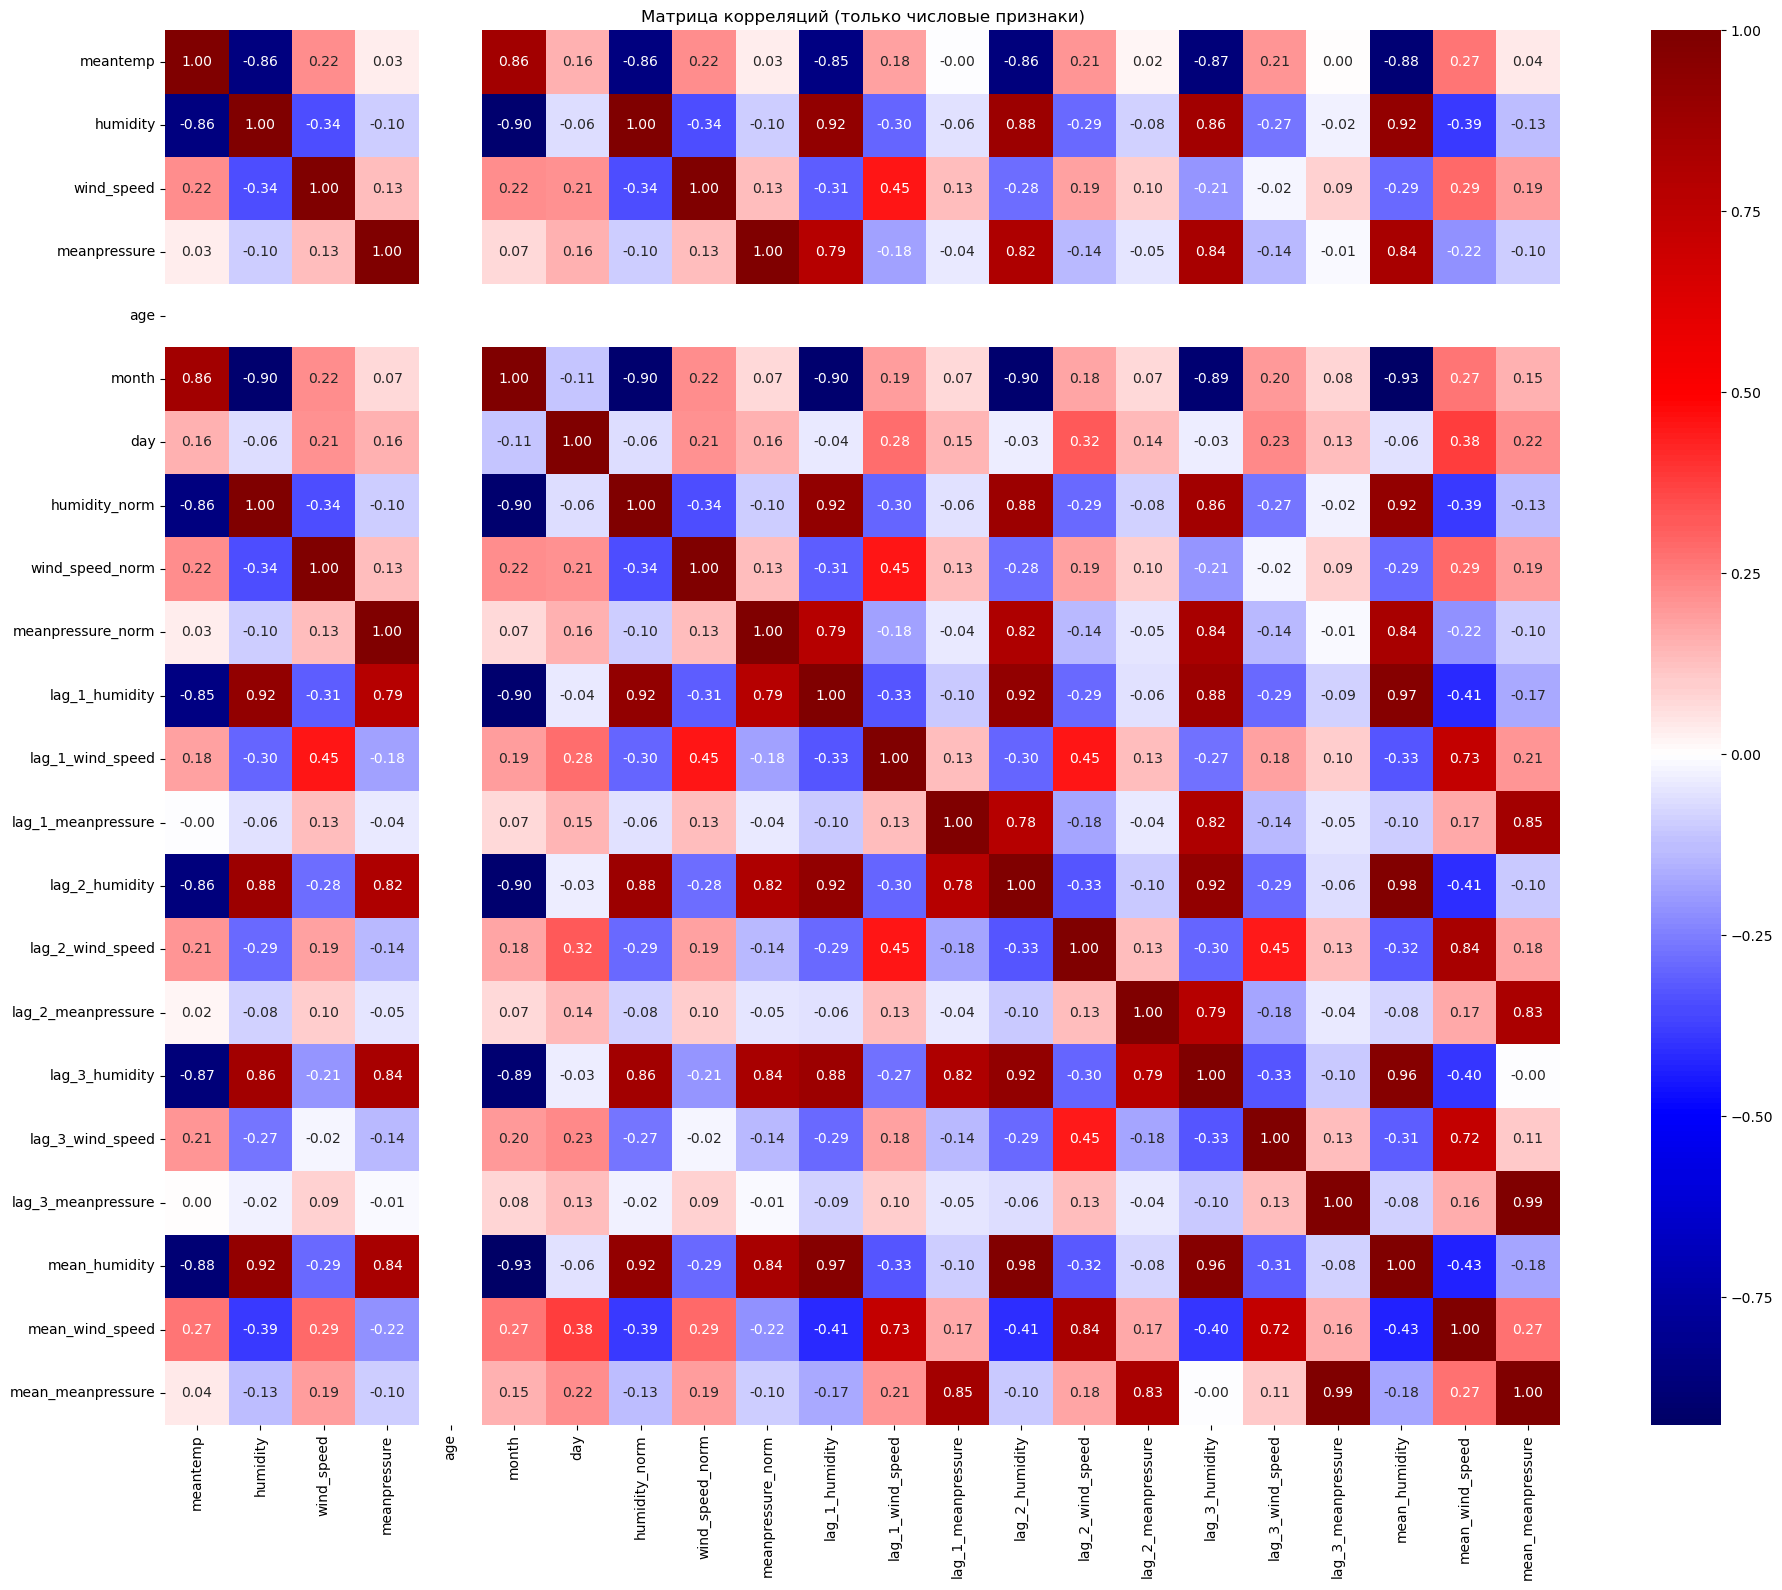

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(20, 16))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='seismic', center=0, fmt='.2f', square=True)
plt.title('Матрица корреляций (только числовые признаки)')
plt.tight_layout()
plt.show()

p-value (level): 0.716476


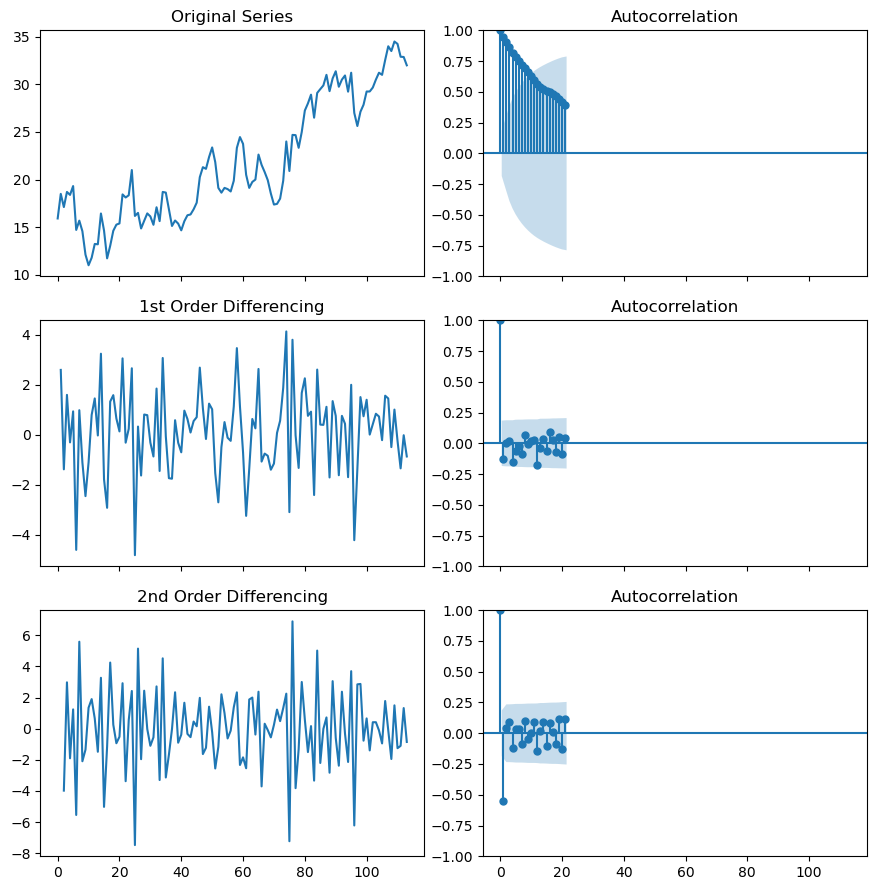

p-value d=1: 0.000000
p-value d=2: 0.000000


In [12]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
series = df["meantemp"]
result_lvl = adfuller(series)
print(f'p-value (level): {result_lvl[1]:.6f}')
fig, axes = plt.subplots(3, 2, sharex=True, figsize=(9, 9))
axes[0, 0].plot(series); axes[0, 0].set_title('Original Series')
plot_acf(series, ax=axes[0, 1])
axes[1, 0].plot(series.diff().dropna()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(series.diff().dropna(), ax=axes[1, 1])
axes[2, 0].plot(series.diff().diff().dropna()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(series.diff().diff().dropna(), ax=axes[2, 1])

plt.tight_layout()
plt.savefig("acf_plots.png", dpi=150)
plt.show()

result_d1 = adfuller(series.diff().dropna())
result_d2 = adfuller(series.diff().diff().dropna())

print(f'p-value d=1: {result_d1[1]:.6f}')
print(f'p-value d=2: {result_d2[1]:.6f}')

<Figure size 700x500 with 0 Axes>

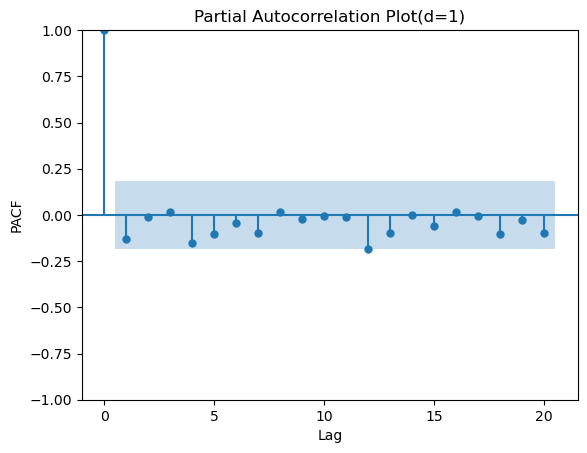

In [13]:
plt.figure(figsize=(7, 5))
plot_pacf(series.diff().dropna(), lags=20)
plt.title("Partial Autocorrelation Plot(d=1)")
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.savefig("pacf_plot_q.png", dpi=150)
plt.show()

In [14]:
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

model_auto = auto_arima(
    series,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=5, max_d=2, max_q=5
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=442.455, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=442.546, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=442.540, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=441.260, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=444.537, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.372 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  114
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -219.630
Date:                Thu, 26 Mar 2026   AIC                            441.260
Time:                        17:58:30   BIC                            443.987
Sample:                             0   HQIC                           442.367
                    

In [15]:
p, d, q = model_auto.order

model_arima = ARIMA(series, order=(p, d, q))
fitted = model_arima.fit()

print(fitted.summary())

future_steps = 14
forecast = fitted.forecast(steps=future_steps)

                               SARIMAX Results                                
Dep. Variable:               meantemp   No. Observations:                  114
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -219.630
Date:                Thu, 26 Mar 2026   AIC                            441.260
Time:                        17:58:52   BIC                            443.987
Sample:                             0   HQIC                           442.367
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         2.8559      0.349      8.186      0.000       2.172       3.540
Ljung-Box (L1) (Q):                   1.92   Jarque-Bera (JB):                 3.63
Prob(Q):                              0.17   Pr

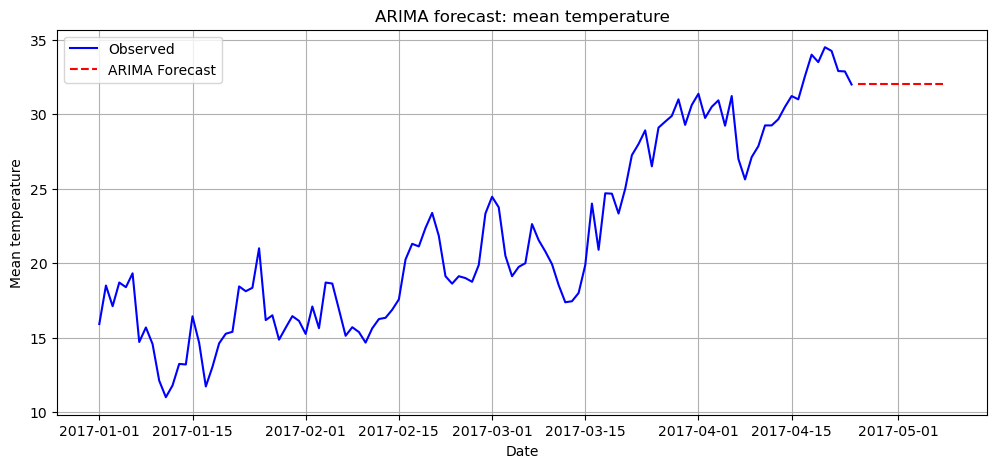

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['meantemp'], label='Observed', color='blue')
plt.plot(
    pd.date_range(df['date'].iloc[-1], periods=future_steps + 1)[1:],
    forecast,
    label='ARIMA Forecast',
    color='red',
    linestyle='--'
)
plt.title('ARIMA forecast: mean temperature')
plt.xlabel('Date')
plt.ylabel('Mean temperature')
plt.legend()
plt.grid(True)
plt.savefig("arima_forecast.png", dpi=150)
plt.show()